In [ ]:
from google.colab import files
files.upload()

Saving crop_data.csv to crop_data.csv


{'crop_data.csv': b'SNo,crop,condition,N,P,K\n1,rice,irrigated,120,60,40\n2,rice,rainfed,84,42,28\n3,wheat,irrigated,150,60,40\n4,wheat,rainfed,105,42,28\n5,maize,irrigated,180,60,50\n6,maize,rainfed,126,42,35\n7,sorghum,irrigated,100,50,40\n8,sorghum,rainfed,70,35,28\n9,bajra,irrigated,90,45,40\n10,bajra,rainfed,63,32,28\n11,ragi,irrigated,80,40,40\n12,ragi,rainfed,56,28,28\n13,barley,irrigated,120,50,40\n14,barley,rainfed,84,35,28\n15,oats,irrigated,100,50,40\n16,oats,rainfed,70,35,28\n17,foxtail millet,irrigated,80,40,40\n18,foxtail millet,rainfed,56,28,28\n19,little millet,irrigated,70,35,35\n20,little millet,rainfed,49,25,25\n21,kodo millet,irrigated,70,35,35\n22,kodo millet,rainfed,49,25,25\n23,barnyard millet,irrigated,70,35,35\n24,barnyard millet,rainfed,49,25,25\n25,proso millet,irrigated,70,35,35\n26,proso millet,rainfed,49,25,25\n27,groundnut,irrigated,30,60,40\n28,groundnut,rainfed,21,42,28\n29,soybean,irrigated,20,60,40\n30,soybean,rainfed,14,42,28\n31,sunflower,irrigated,


🌱 RDF + ADJUSTED RDF SYSTEM

Available Crops:
1. alfalfa
2. amaranthus
3. arhar
4. ash gourd
5. baby corn
6. bajra
7. barley
8. barnyard millet
9. basella
10. beetroot
11. berseem
12. bitter gourd
13. black carrot
14. black gram fodder
15. bottle gourd
16. brinjal
17. broccoli
18. broccoli microgreens
19. buckwheat
20. cabbage
21. canola
22. carrot
23. castor
24. cauliflower
25. celery
26. cherry tomato
27. chickpea
28. chilli
29. chives
30. clover
31. cluster bean
32. cluster bean vegetable
33. colocasia
34. coriander
35. cowpea
36. cowpea fodder
37. cowpea vegetable
38. cucumber
39. curry leaf (annual nursery)
40. desi cucumber
41. desmanthus
42. drumstick (annual)
43. fenugreek
44. fenugreek greens
45. field bean
46. field bean vegetable
47. field pea (grain)
48. foxtail millet
49. french bean
50. french bean vegetable
51. garlic
52. garlic greens
53. gram
54. grass pea
55. green cabbage
56. green chilli
57. green gram fodder
58. green pea (veg)
59. groundnut
60. guinea grass
61. h

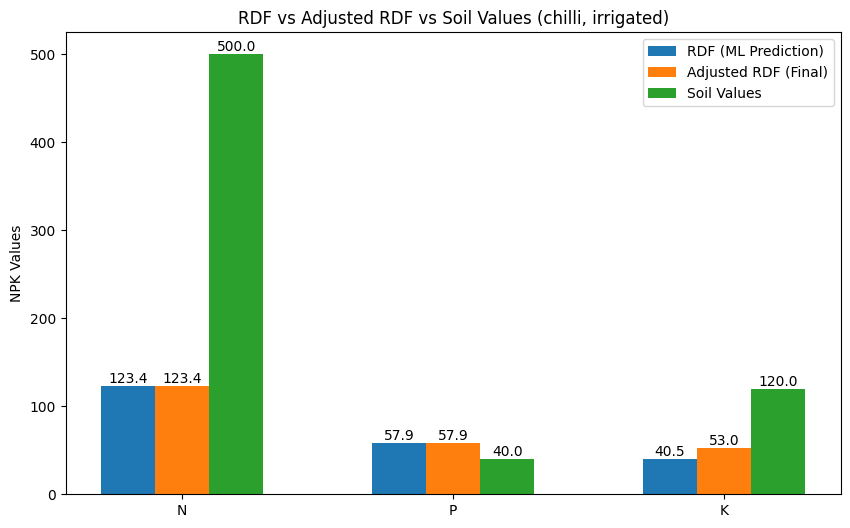

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv("crop_data.csv")
df.columns = df.columns.str.strip()
df = df.dropna()

# -----------------------------
# ONE HOT ENCODING
# -----------------------------
df = pd.get_dummies(df, columns=['crop', 'condition'])

# -----------------------------
# FEATURES & TARGET (RDF from dataset)
# -----------------------------
X = df.drop(columns=['N', 'P', 'K'])
y_N = df['N']
y_P = df['P']
y_K = df['K']

# -----------------------------
# TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, yN_train, yN_test = train_test_split(X, y_N, test_size=0.3, random_state=42)
X_train, X_test, yP_train, yP_test = train_test_split(X, y_P, test_size=0.3, random_state=42)
X_train, X_test,yK_train, yK_test = train_test_split(X, y_K, test_size=0.3, random_state=42)

# -----------------------------
# RANDOM FOREST MODEL
# -----------------------------
model_N = RandomForestRegressor(n_estimators=1000, random_state=42)
model_P = RandomForestRegressor(n_estimators=1000, random_state=42)
model_K = RandomForestRegressor(n_estimators=1000, random_state=42)

model_N.fit(X_train, yN_train)
model_P.fit(X_train, yP_train)
model_K.fit(X_train, yK_train)

# -----------------------------
# USER INPUT
# -----------------------------
print("\n==============================")
print("🌱 RDF + ADJUSTED RDF SYSTEM")
print("==============================")

crop_cols = [c.replace("crop_", "") for c in X.columns if "crop_" in c]
cond_cols = [c.replace("condition_", "") for c in X.columns if "condition_" in c]

print("\nAvailable Crops:")
for i, c in enumerate(crop_cols):
    print(f"{i+1}. {c}")

crop = crop_cols[int(input("\nEnter crop number: ")) - 1]

print("\nAvailable Conditions:")
for i, c in enumerate(cond_cols):
    print(f"{i+1}. {c}")

condition = cond_cols[int(input("\nEnter condition number: ")) - 1]

soil_N = float(input("\nEnter soil N: "))
soil_P = float(input("Enter soil P: "))
soil_K = float(input("Enter soil K: "))

# -----------------------------
# INPUT VECTOR
# -----------------------------
input_data = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)
input_data["crop_" + crop] = 1
input_data["condition_" + condition] = 1

# -----------------------------
# PREDICT RDF (FROM DATASET MODEL)
# -----------------------------
rdf_N = model_N.predict(input_data)[0]
rdf_P = model_P.predict(input_data)[0]
rdf_K = model_K.predict(input_data)[0]

# -----------------------------
# LMH CLASSIFICATION (SOIL)
# -----------------------------
def classify_N(x):
    if x < 280: return "Low"
    elif x <= 560: return "Medium"
    else: return "High"

def classify_P(x):
    if x < 22.9: return "Low"
    elif x <= 55.33: return "Medium"
    else: return "High"

def classify_K(x):
    if x < 141: return "Low"
    elif x <= 336: return "Medium"
    else: return "High"

soil_N_class = classify_N(soil_N)
soil_P_class = classify_P(soil_P)
soil_K_class = classify_K(soil_K)

# -----------------------------
# AGRONOMY ADJUSTMENT (YOUR RULE TABLE)
# -----------------------------
def adjust_N(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf <= 50: return 0
        elif rdf <= 100: return 12.5
        elif rdf <= 175: return 25
        elif rdf <= 250: return 37.5
        else: return 50
    else:
        if rdf <= 50: return 0
        elif rdf <= 100: return -12.5
        elif rdf <= 175: return -25
        elif rdf <= 250: return -37.5
        else: return -50

def adjust_P(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf < 25: return 0
        elif rdf <= 75: return 12.5
        else: return 25
    else:
        if rdf < 25: return 0
        elif rdf <= 75: return -12.5
        else: return -25

def adjust_K(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf < 25: return 0
        elif rdf <= 50: return 12.5
        elif rdf <= 100: return 25
        elif rdf <= 175: return 37.5
        else: return 37.5
    else:
        if rdf < 25: return 0
        elif rdf <= 50: return -12.5
        elif rdf <= 100: return -25
        elif rdf <= 175: return -37.5
        else: return -37.5

adjusted_N = rdf_N + adjust_N(rdf_N, soil_N_class)
adjusted_P = rdf_P + adjust_P(rdf_P, soil_P_class)
adjusted_K = rdf_K + adjust_K(rdf_K, soil_K_class)

# -----------------------------
# OUTPUT
# -----------------------------
print("\n==============================")
print("🌾 RDF vs ADJUSTED RDF")
print("==============================")

print("\nRDF (From Dataset Model):")
print("N:", round(rdf_N, 2))
print("P:", round(rdf_P, 2))
print("K:", round(rdf_K, 2))

print("\nAdjusted RDF (Final Recommendation):")
print("N:", round(adjusted_N, 2))
print("P:", round(adjusted_P, 2))
print("K:", round(adjusted_K, 2))

# -----------------------------
# PERFORMANCE
# -----------------------------
pred_N = model_N.predict(X_test)
pred_P = model_P.predict(X_test)
pred_K = model_K.predict(X_test)

def report(name, y_true, y_pred):
    print(f"\n📊 {name}")
    print("R2:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))

print("\n==============================")
print("🔥 MODEL PERFORMANCE (RDF MODEL)")
print("==============================")

report("N", yN_test, pred_N)
report("P", yP_test, pred_P)
report("K", yK_test, pred_K)

# -----------------------------
# GRAPH
# -----------------------------
labels = ["N", "P", "K"]

rdf = [rdf_N, rdf_P, rdf_K]
adj = [adjusted_N, adjusted_P, adjusted_K]
soil = [soil_N, soil_P, soil_K] # Add soil values

x = np.arange(len(labels))

plt.figure(figsize=(10,6))

plt.bar(x - 0.2, rdf, 0.2, label="RDF (ML Prediction)") # Shift RDF bars left
plt.bar(x, adj, 0.2, label="Adjusted RDF (Final)") # Keep Adjusted RDF bars in the center
plt.bar(x + 0.2, soil, 0.2, label="Soil Values") # Shift Soil Value bars right

plt.xticks(x, labels)
plt.title(f"RDF vs Adjusted RDF vs Soil Values ({crop}, {condition})") # Update title
plt.ylabel("NPK Values") # Add Y-axis label
plt.legend()

for i in range(len(labels)):
    plt.text(x[i] - 0.2, rdf[i], round(rdf[i],1), ha='center', va='bottom')
    plt.text(x[i], adj[i], round(adj[i],1), ha='center', va='bottom')
    plt.text(x[i] + 0.2, soil[i], round(soil[i],1), ha='center', va='bottom')

plt.show()


🌱 RDF + ADJUSTED RDF SYSTEM

Available Crops:
1. alfalfa
2. amaranthus
3. arhar
4. ash gourd
5. baby corn
6. bajra
7. barley
8. barnyard millet
9. basella
10. beetroot
11. berseem
12. bitter gourd
13. black carrot
14. black gram fodder
15. bottle gourd
16. brinjal
17. broccoli
18. broccoli microgreens
19. buckwheat
20. cabbage
21. canola
22. carrot
23. castor
24. cauliflower
25. celery
26. cherry tomato
27. chickpea
28. chilli
29. chives
30. clover
31. cluster bean
32. cluster bean vegetable
33. colocasia
34. coriander
35. cowpea
36. cowpea fodder
37. cowpea vegetable
38. cucumber
39. curry leaf (annual nursery)
40. desi cucumber
41. desmanthus
42. drumstick (annual)
43. fenugreek
44. fenugreek greens
45. field bean
46. field bean vegetable
47. field pea (grain)
48. foxtail millet
49. french bean
50. french bean vegetable
51. garlic
52. garlic greens
53. gram
54. grass pea
55. green cabbage
56. green chilli
57. green gram fodder
58. green pea (veg)
59. groundnut
60. guinea grass
61. h

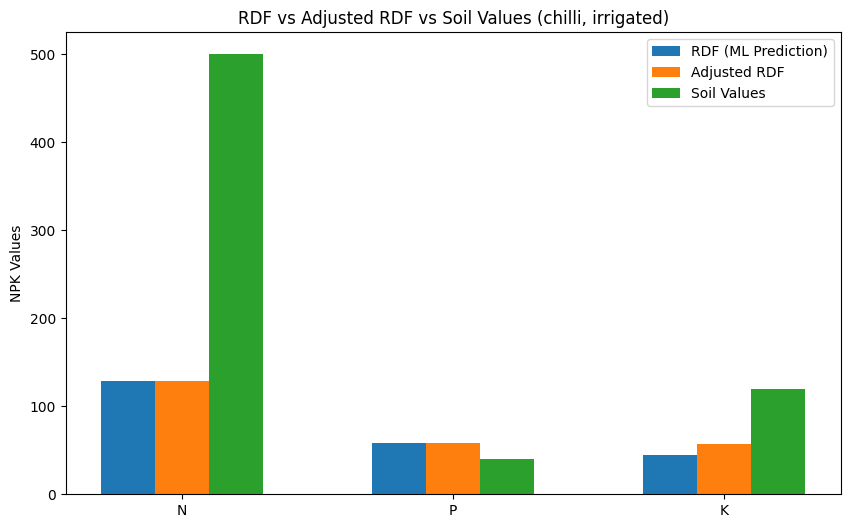

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv("crop_data.csv")
df.columns = df.columns.str.strip()
df = df.dropna()

# -----------------------------
# ONE HOT ENCODING
# -----------------------------
df = pd.get_dummies(df, columns=['crop', 'condition'])

# -----------------------------
# FEATURES & TARGET
# -----------------------------
X = df.drop(columns=['N', 'P', 'K'])
y_N = df['N']
y_P = df['P']
y_K = df['K']

# -----------------------------
# TRAIN MODELS (NO TEST SPLIT)
# -----------------------------
model_N = RandomForestRegressor(n_estimators=500, random_state=42)
model_P = RandomForestRegressor(n_estimators=500, random_state=42)
model_K = RandomForestRegressor(n_estimators=500, random_state=42)

model_N.fit(X, y_N)
model_P.fit(X, y_P)
model_K.fit(X, y_K)

# -----------------------------
# USER INPUT
# -----------------------------
print("\n==============================")
print("🌱 RDF + ADJUSTED RDF SYSTEM")
print("==============================")

crop_cols = [c.replace("crop_", "") for c in X.columns if "crop_" in c]
cond_cols = [c.replace("condition_", "") for c in X.columns if "condition_" in c]

print("\nAvailable Crops:")
for i, c in enumerate(crop_cols):
    print(f"{i+1}. {c}")

crop = crop_cols[int(input("\nEnter crop number: ")) - 1]

print("\nAvailable Conditions:")
for i, c in enumerate(cond_cols):
    print(f"{i+1}. {c}")

condition = cond_cols[int(input("\nEnter condition number: ")) - 1]

soil_N = float(input("\nEnter soil N: "))
soil_P = float(input("Enter soil P: "))
soil_K = float(input("Enter soil K: "))

# -----------------------------
# INPUT VECTOR
# -----------------------------
input_data = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)
input_data["crop_" + crop] = 1
input_data["condition_" + condition] = 1

# -----------------------------
# PREDICTION
# -----------------------------
rdf_N = model_N.predict(input_data)[0]
rdf_P = model_P.predict(input_data)[0]
rdf_K = model_K.predict(input_data)[0]

# -----------------------------
# LMH CLASSIFICATION
# -----------------------------
def classify_N(x):
    if x < 280: return "Low"
    elif x <= 560: return "Medium"
    else: return "High"

def classify_P(x):
    if x < 22.9: return "Low"
    elif x <= 55.33: return "Medium"
    else: return "High"

def classify_K(x):
    if x < 141: return "Low"
    elif x <= 336: return "Medium"
    else: return "High"

soil_N_class = classify_N(soil_N)
soil_P_class = classify_P(soil_P)
soil_K_class = classify_K(soil_K)

# -----------------------------
# ADJUSTMENT RULES
# -----------------------------
def adjust_N(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf <= 50: return 0
        elif rdf <= 100: return 12.5
        elif rdf <= 175: return 25
        elif rdf <= 250: return 37.5
        else: return 50
    else:
        if rdf <= 50: return 0
        elif rdf <= 100: return -12.5
        elif rdf <= 175: return -25
        elif rdf <= 250: return -37.5
        else: return -50

def adjust_P(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf < 25: return 0
        elif rdf <= 75: return 12.5
        else: return 25
    else:
        if rdf < 25: return 0
        elif rdf <= 75: return -12.5
        else: return -25

def adjust_K(rdf, soil):
    if soil == "Medium": return 0
    if soil == "Low":
        if rdf < 25: return 0
        elif rdf <= 50: return 12.5
        elif rdf <= 100: return 25
        elif rdf <= 175: return 37.5
        else: return 37.5
    else:
        if rdf < 25: return 0
        elif rdf <= 50: return -12.5
        elif rdf <= 100: return -25
        elif rdf <= 175: return -37.5
        else: return -37.5

adjusted_N = rdf_N + adjust_N(rdf_N, soil_N_class)
adjusted_P = rdf_P + adjust_P(rdf_P, soil_P_class)
adjusted_K = rdf_K + adjust_K(rdf_K, soil_K_class)

# -----------------------------
# OUTPUT
# -----------------------------
print("\n==============================")
print("🌾 RDF vs ADJUSTED RDF")
print("==============================")

print("\nRDF (From Model):")
print("N:", round(rdf_N, 2))
print("P:", round(rdf_P, 2))
print("K:", round(rdf_K, 2))

print("\nAdjusted RDF (Final Recommendation):")
print("N:", round(adjusted_N, 2))
print("P:", round(adjusted_P, 2))
print("K:", round(adjusted_K, 2))

# -----------------------------
# GRAPH
# -----------------------------
labels = ["N", "P", "K"]

rdf = [rdf_N, rdf_P, rdf_K]
adj = [adjusted_N, adjusted_P, adjusted_K]
soil = [soil_N, soil_P, soil_K]

x = np.arange(len(labels))

plt.figure(figsize=(10,6))

plt.bar(x - 0.2, rdf, 0.2, label="RDF (ML Prediction)")
plt.bar(x, adj, 0.2, label="Adjusted RDF")
plt.bar(x + 0.2, soil, 0.2, label="Soil Values")

plt.xticks(x, labels)
plt.title(f"RDF vs Adjusted RDF vs Soil Values ({crop}, {condition})")
plt.ylabel("NPK Values")
plt.legend()

plt.show()